# Requirements

In [1]:
!pip install albumentations scikit-image torchmetrics netCDF4 --quiet
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import netCDF4 as nc
from tqdm import tqdm
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
from PIL import Image

# GPU SETUP
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [3]:
class SatelliteDataset(Dataset):
    def __init__(self, file_list, hr_size=128, scale=4):
        self.files = file_list
        self.hr_size = hr_size
        self.lr_size = hr_size // scale
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            ds = nc.Dataset(self.files[idx])
            var = [v for v in ds.variables 
                   if len(ds.variables[v].shape) >= 2][-1]
            data = ds.variables[var][:]
            if len(data.shape) > 2:
                data = data[0]
            data = np.array(data, dtype=np.float32)
            data = np.nan_to_num(data)
            mn, mx = data.min(), data.max()
            if mx > mn:
                data = (data - mn) / (mx - mn)
            img = Image.fromarray(
                (data * 255).astype(np.uint8)).convert('RGB')
            hr = img.resize((self.hr_size, self.hr_size), Image.BICUBIC)
            lr = img.resize((self.lr_size, self.lr_size), Image.BICUBIC)
            return self.to_tensor(lr), self.to_tensor(hr)
        except:
            lr = torch.zeros(3, self.lr_size, self.lr_size)
            hr = torch.zeros(3, self.hr_size, self.hr_size)
            return lr, hr

# Load files
base = '/kaggle/input/satellite-nc-x10-dataset'
all_files = []
for root, _, files in os.walk(base + '/data'):
    for f in files:
        if f.endswith('.nc'):
            all_files.append(os.path.join(root, f))

np.random.shuffle(all_files)
n = len(all_files)
train_files = all_files[:int(0.7*n)]
val_files   = all_files[int(0.7*n):int(0.85*n)]
test_files  = all_files[int(0.85*n):]

# More workers for GPU training
train_loader = DataLoader(SatelliteDataset(train_files), 
                          batch_size=16, shuffle=True, 
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(SatelliteDataset(val_files),   
                          batch_size=1, num_workers=2)
test_loader  = DataLoader(SatelliteDataset(test_files),  
                          batch_size=1, num_workers=2)
print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Train: 1374, Val: 294, Test: 295


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch, 3, 1, 1)
        )
    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, scale=4, num_blocks=16):
        super().__init__()
        self.head = nn.Conv2d(3, 64, 3, 1, 1)
        self.body = nn.Sequential(
            *[ResBlock() for _ in range(num_blocks)])
        ups = []
        for _ in range(int(np.log2(scale))):
            ups += [nn.Conv2d(64, 256, 3, 1, 1),
                    nn.PixelShuffle(2),
                    nn.LeakyReLU(0.2, inplace=True)]
        self.upsample = nn.Sequential(*ups)
        self.tail = nn.Sequential(
            nn.Conv2d(64, 3, 3, 1, 1), nn.Sigmoid())

    def forward(self, x):
        x = self.head(x)
        x = self.body(x) + x
        x = self.upsample(x)
        return self.tail(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Move models to GPU
gen  = Generator(scale=4, num_blocks=16).to(device)
disc = Discriminator().to(device)

# Use DataParallel if multiple GPUs available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    gen  = nn.DataParallel(gen)
    disc = nn.DataParallel(disc)

opt_gen  = torch.optim.Adam(gen.parameters(),  lr=1e-4, betas=(0.9, 0.999))
opt_disc = torch.optim.Adam(disc.parameters(), lr=1e-4, betas=(0.9, 0.999))

# Learning rate schedulers
scheduler_gen  = torch.optim.lr_scheduler.StepLR(opt_gen,  step_size=10, gamma=0.5)
scheduler_disc = torch.optim.lr_scheduler.StepLR(opt_disc, step_size=10, gamma=0.5)

total_params = sum(p.numel() for p in gen.parameters())
print(f"Generator parameters: {total_params:,}")
print("Models ready on GPU!")

Using 2 GPUs!
Generator parameters: 1,480,643
Models ready on GPU!


In [5]:
psnr_history, ssim_history, loss_g_history, loss_d_history = [], [], [], []

psnr_m = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_m = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
l1     = nn.L1Loss()
bce    = nn.BCELoss()

NUM_EPOCHS = 20
best_psnr  = 0.0

print(f"Starting training for {NUM_EPOCHS} epochs on {device}...")

for epoch in range(NUM_EPOCHS):
    gen.train()
    disc.train()
    psnr_m.reset()
    ssim_m.reset()
    epoch_loss_g = 0
    epoch_loss_d = 0
    count = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for lr_img, hr_img in loop:
        lr_img = lr_img.to(device, non_blocking=True)
        hr_img = hr_img.to(device, non_blocking=True)

        # === Train Discriminator ===
        opt_disc.zero_grad()
        fake = gen(lr_img).detach()
        real_loss = bce(disc(hr_img),
                        torch.ones_like(disc(hr_img)))
        fake_loss = bce(disc(fake),
                        torch.zeros_like(disc(fake)))
        loss_d = (real_loss + fake_loss) / 2
        loss_d.backward()
        opt_disc.step()

        # === Train Generator ===
        opt_gen.zero_grad()
        fake = gen(lr_img)
        pixel_loss = l1(fake, hr_img)
        adv_loss   = 1e-3 * bce(disc(fake),
                                  torch.ones_like(disc(fake)))
        loss_g = pixel_loss + adv_loss
        loss_g.backward()
        opt_gen.step()

        with torch.no_grad():
            psnr_m.update(fake.clamp(0,1), hr_img)
            ssim_m.update(fake.clamp(0,1), hr_img)

        epoch_loss_g += loss_g.item()
        epoch_loss_d += loss_d.item()
        count += 1

        loop.set_postfix(
            Loss_G=f"{loss_g.item():.4f}",
            Loss_D=f"{loss_d.item():.4f}"
        )

        # Free GPU memory
        del fake, real_loss, fake_loss, loss_d
        del pixel_loss, adv_loss, loss_g
        torch.cuda.empty_cache()

    psnr_val = psnr_m.compute().item()
    ssim_val = ssim_m.compute().item()
    avg_lg   = epoch_loss_g / count
    avg_ld   = epoch_loss_d / count

    psnr_history.append(psnr_val)
    ssim_history.append(ssim_val)
    loss_g_history.append(avg_lg)
    loss_d_history.append(avg_ld)

    scheduler_gen.step()
    scheduler_disc.step()

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"PSNR: {psnr_val:.2f} dB | "
          f"SSIM: {ssim_val:.4f} | "
          f"Loss_G: {avg_lg:.4f} | "
          f"Loss_D: {avg_ld:.4f}")

    # Save best model
    if psnr_val > best_psnr:
        best_psnr = psnr_val
        torch.save(gen.state_dict(), '/kaggle/working/best_gen.pth')
        print(f"  Best model saved! PSNR: {best_psnr:.2f} dB")

print(f"\nTraining complete! Best PSNR: {best_psnr:.2f} dB")

Starting training for 20 epochs on cuda...


Epoch 1/20: 100%|██████████| 86/86 [21:18<00:00, 14.87s/it, Loss_D=0.3958, Loss_G=0.0698]


Epoch  1/20 | PSNR: 17.43 dB | SSIM: 0.2983 | Loss_G: 0.0993 | Loss_D: 0.4782
  Best model saved! PSNR: 17.43 dB


Epoch 2/20: 100%|██████████| 86/86 [21:00<00:00, 14.66s/it, Loss_D=0.2620, Loss_G=0.0552]


Epoch  2/20 | PSNR: 21.45 dB | SSIM: 0.4245 | Loss_G: 0.0610 | Loss_D: 0.3139
  Best model saved! PSNR: 21.45 dB


...

Epoch 18/20 | PSNR: 23.62 dB | SSIM: 0.5942 | Loss_G: 0.0491 | Loss_D: 0.0102


Epoch 19/20: 100%|██████████| 86/86 [23:14<00:00, 16.22s/it, Loss_D=0.0092, Loss_G=0.0441]


Epoch 19/20 | PSNR: 23.62 dB | SSIM: 0.5943 | Loss_G: 0.0491 | Loss_D: 0.0094
  Best model saved! PSNR: 23.62 dB


Epoch 20/20: 100%|██████████| 86/86 [23:37<00:00, 16.49s/it, Loss_D=0.0225, Loss_G=0.0397]

Epoch 20/20 | PSNR: 23.62 dB | SSIM: 0.5945 | Loss_G: 0.0493 | Loss_D: 0.0091

Training complete! Best PSNR: 23.62 dB


In [9]:
def bicubic_upsample(lr_tensor, scale=4):
    result = []
    for i in range(lr_tensor.shape[0]):
        img = transforms.ToPILImage()(lr_tensor[i].cpu())
        w, h = img.size
        img = img.resize((w*scale, h*scale), Image.BICUBIC)
        result.append(transforms.ToTensor()(img))
    return torch.stack(result)

def nearest_upsample(lr_tensor, scale=4):
    result = []
    for i in range(lr_tensor.shape[0]):
        img = transforms.ToPILImage()(lr_tensor[i].cpu())
        w, h = img.size
        img = img.resize((w*scale, h*scale), Image.NEAREST)
        result.append(transforms.ToTensor()(img))
    return torch.stack(result)

gen.eval()
esrgan_psnrs,  bicubic_psnrs,  nearest_psnrs  = [], [], []
esrgan_ssims,  bicubic_ssims,  nearest_ssims   = [], [], []

print("Evaluating on test set...")
with torch.no_grad():
    for i, (lr_img, hr_img) in enumerate(tqdm(test_loader)):
        if i >= 100: break
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        fake = gen(lr_img).clamp(0, 1)
        bic  = bicubic_upsample(lr_img).to(device)
        near = nearest_upsample(lr_img).to(device)

        for pred, pl, sl in [
            (fake, esrgan_psnrs,  esrgan_ssims),
            (bic,  bicubic_psnrs, bicubic_ssims),
            (near, nearest_psnrs, nearest_ssims)
        ]:
            psnr_m.reset(); ssim_m.reset()
            psnr_m.update(pred, hr_img)
            ssim_m.update(pred, hr_img)
            pl.append(psnr_m.compute().item())
            sl.append(ssim_m.compute().item())

print("\n========== COMPARATIVE ANALYSIS ==========")
print(f"{'Method':<20} {'PSNR (dB)':<15} {'SSIM'}")
print("-" * 45)
for name, ps, ss in [
    ("ESRGAN (Ours)",  esrgan_psnrs,  esrgan_ssims),
    ("Bicubic",        bicubic_psnrs, bicubic_ssims),
    ("Nearest-Neighbour", nearest_psnrs, nearest_ssims)
]:
    print(f"{name:<20} {np.mean(ps):<15.2f} {np.mean(ss):.4f}")
print("==========================================")

Evaluating on test set...


 34%|███▍      | 100/295 [01:45<03:26,  1.06s/it]


========== COMPARATIVE ANALYSIS ==========
Method               PSNR (dB)       SSIM
---------------------------------------------
ESRGAN (Ours)        25.80           0.6274
Bicubic              25.67           0.5813
Nearest-Neighbour    24.94           0.5501


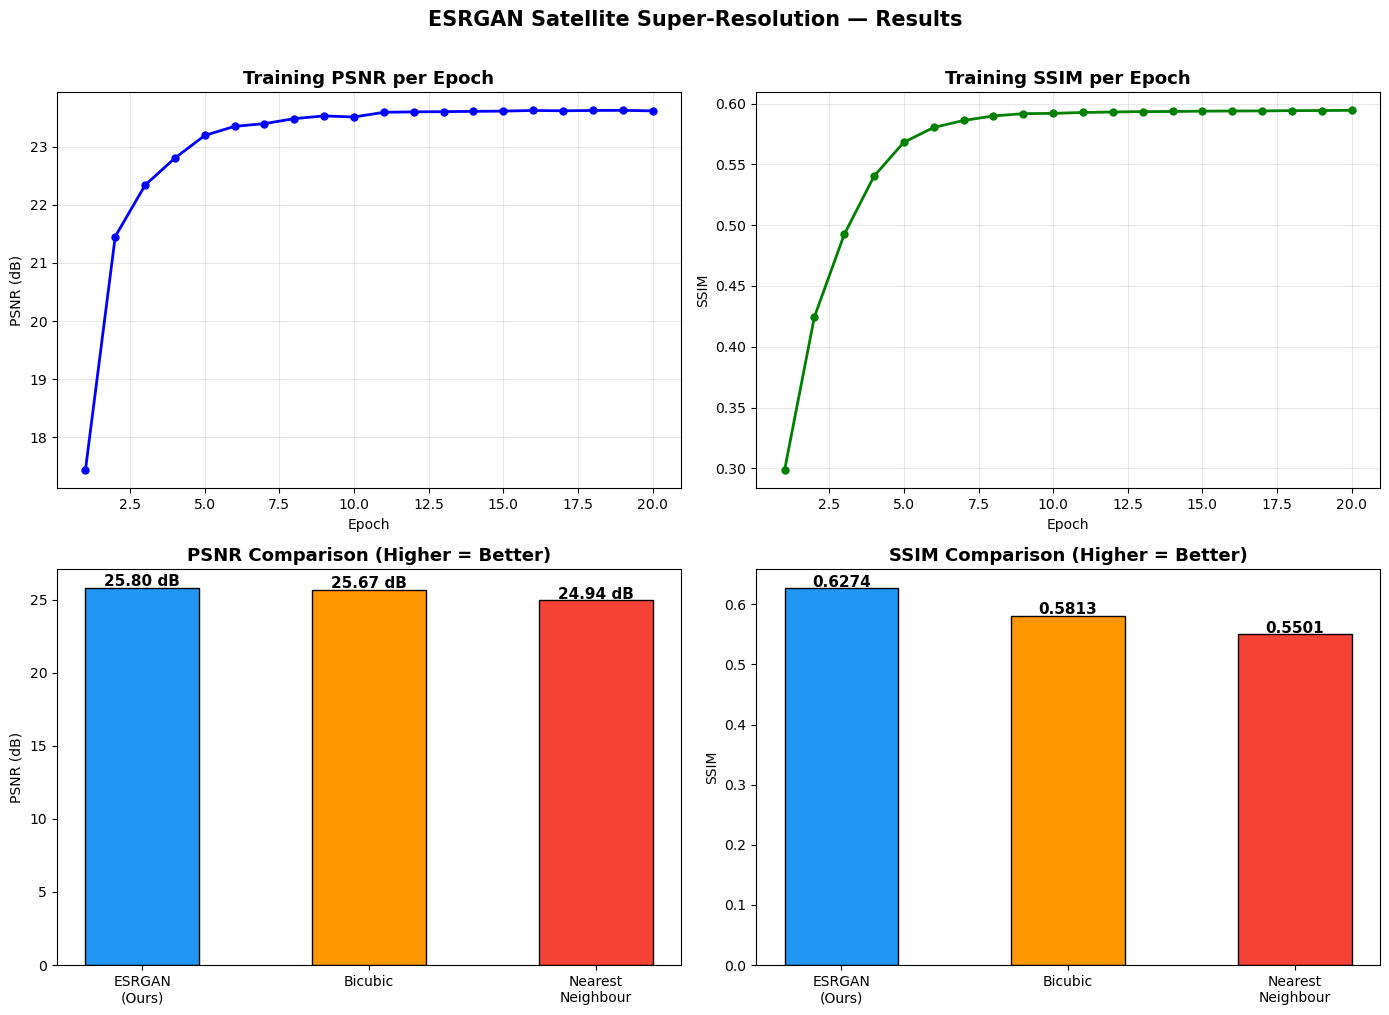

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR
axes[0,0].plot(range(1, NUM_EPOCHS+1), psnr_history, 
               'b-o', linewidth=2, markersize=5)
axes[0,0].set_title('Training PSNR per Epoch', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('PSNR (dB)')
axes[0,0].grid(True, alpha=0.3)

# SSIM
axes[0,1].plot(range(1, NUM_EPOCHS+1), ssim_history, 
               'g-o', linewidth=2, markersize=5)
axes[0,1].set_title('Training SSIM per Epoch', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('SSIM')
axes[0,1].grid(True, alpha=0.3)

# PSNR Comparison Bar Chart
methods   = ['ESRGAN\n(Ours)', 'Bicubic', 'Nearest\nNeighbour']
psnr_vals = [np.mean(esrgan_psnrs), 
             np.mean(bicubic_psnrs), 
             np.mean(nearest_psnrs)]
colors    = ['#2196F3', '#FF9800', '#F44336']
bars = axes[1,0].bar(methods, psnr_vals, color=colors, 
                      edgecolor='black', width=0.5)
axes[1,0].set_title('PSNR Comparison (Higher = Better)', 
                     fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('PSNR (dB)')
for bar, val in zip(bars, psnr_vals):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.2f} dB', ha='center', 
                   fontweight='bold', fontsize=11)

# SSIM Comparison Bar Chart
ssim_vals = [np.mean(esrgan_ssims), 
             np.mean(bicubic_ssims), 
             np.mean(nearest_ssims)]
bars2 = axes[1,1].bar(methods, ssim_vals, color=colors, 
                       edgecolor='black', width=0.5)
axes[1,1].set_title('SSIM Comparison (Higher = Better)', 
                     fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('SSIM')
for bar, val in zip(bars2, ssim_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.002,
                   f'{val:.4f}', ha='center', 
                   fontweight='bold', fontsize=11)

plt.suptitle('ESRGAN Satellite Super-Resolution — Results', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=150, bbox_inches='tight')
plt.show()

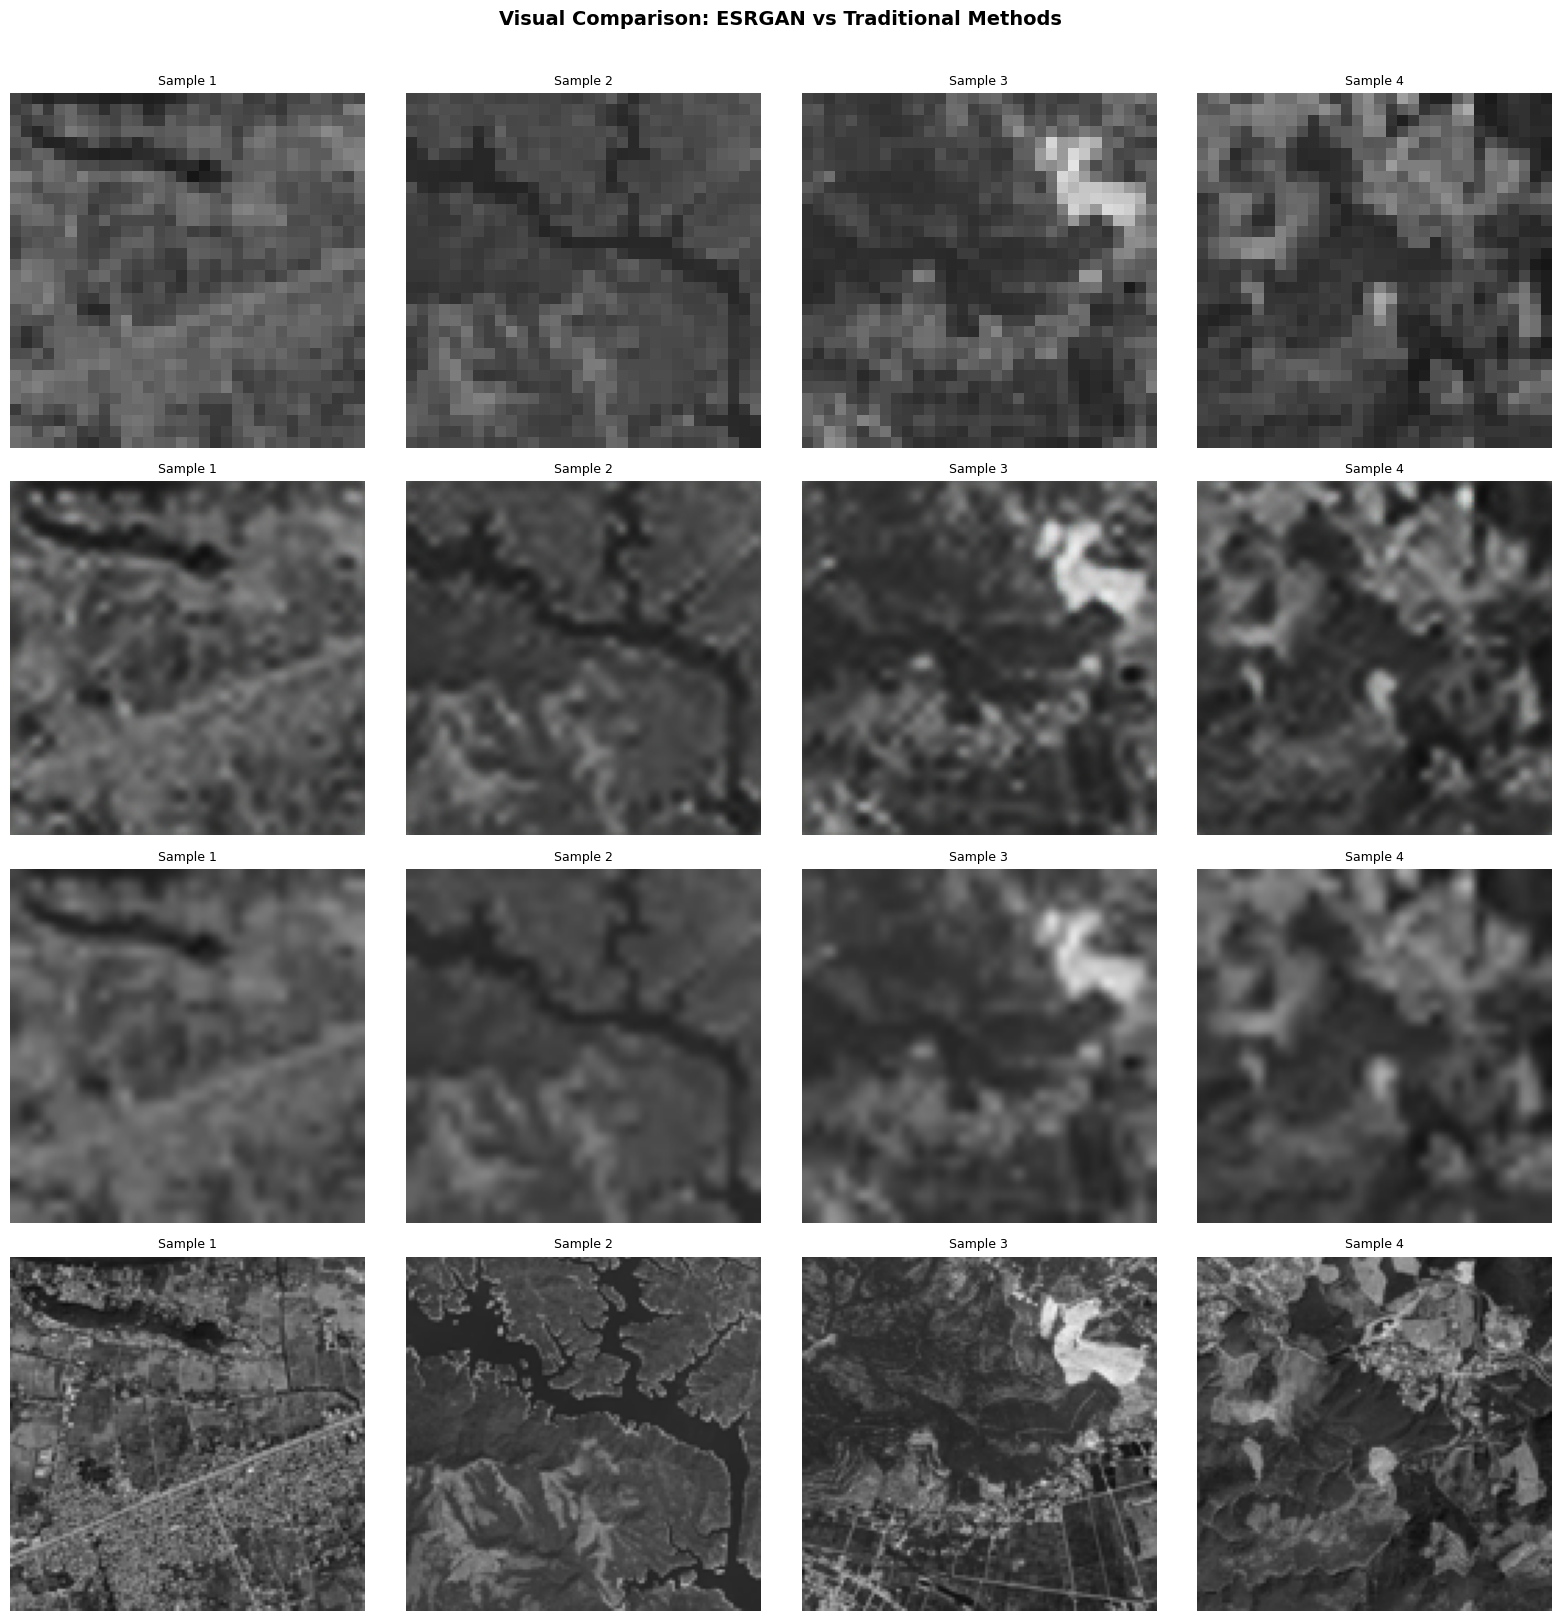

All results saved to /kaggle/working/


In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
titles = ['Low-Res Input', 'ESRGAN (Ours)', 'Bicubic', 'Ground Truth']

gen.eval()
with torch.no_grad():
    for col, (lr_img, hr_img) in enumerate(test_loader):
        if col >= 4: break
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        fake = gen(lr_img).clamp(0, 1)
        bic  = bicubic_upsample(lr_img).to(device)
        imgs = [lr_img, fake, bic, hr_img]

        for row, img in enumerate(imgs):
            axes[row, col].imshow(
                img[0].cpu().permute(1, 2, 0).numpy())
            if col == 0:
                axes[row, col].set_ylabel(
                    titles[row], fontsize=11, fontweight='bold')
            axes[row, col].set_title(f'Sample {col+1}', fontsize=9)
            axes[row, col].axis('off')

plt.suptitle('Visual Comparison: ESRGAN vs Traditional Methods',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/visual_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("All results saved to /kaggle/working/")